# CausalPFN — who are the negative-CATE patients? (barc_235 & bleed)

Notebook `08_CausalFPN.ipynb` found a **positive** (harmful) average effect of prolonged DAPT
on both bleeding endpoints — `barc_235` (BARC type 2/3/5 bleeding) and `bleed` — but part of the
predicted per-patient CATE distribution sits below zero, meaning the model assigns a negative
(protective) predicted effect to some patients even though prolonged DAPT is harmful on average.

This notebook isolates that **negative-CATE group** for the two bleeding endpoints and asks a
purely descriptive question: **what, if anything, distinguishes these patients from the rest of
the cohort?**

> **Result preview, corrected after running:** this is *not* a small tail. §3-4 show the
> negative-CATE group is **44.7% of the cohort for both endpoints** (2047/4579 patients) — the
> low ATE (barc_235 +0.021, bleed +0.043) sits inside a CATE distribution wide enough that the
> sign is close to a coin flip for a large share of patients, not a rare edge case.

> **Important caveat carried over from `08_CausalFPN.ipynb` §7–8:** the RATE/TOC curves hug
> zero (AUTOC ≈ 0) and no covariate has more than a weak Spearman correlation (|ρ| ≤ 0.213)
> with the predicted CATE — i.e. this heterogeneity is **not statistically validated** on a
> held-out split, in agreement with the T-learner and causal forest
> (`../causal_forest/NOTES_heterogeneity.md`). Read everything below as *"what does the model's
> in-sample sign split correlate with"*, **not** as a validated responder subgroup — it should
> not drive subgroup-specific clinical claims.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

import torch
from causalpfn import CATEEstimator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from IPython.display import display

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))
SAVE_DIR = os.path.join(MODELS_DIR, 'CausalFPN')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

print(f'Running CausalPFN on: {DEVICE}')

Running CausalPFN on: cpu


/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data, treatment and the two bleeding endpoints

In [2]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = ['cec_barc235_335d', 'cec_bleed_335d']
TARGET_LABELS = ['barc_235', 'bleed']
ENDPOINTS = list(zip(TARGETS, TARGET_LABELS))

y_df = y_df[TARGETS]

# CausalPFN consumes a numeric design matrix only (same as notebook 08)
X_num = X.select_dtypes(include=[np.number])

# Binary treatment: prolonged (1) vs. abbreviated (0) DAPT
T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()

print(f'Samples: {len(X_num)}, Features: {X_num.shape[1]}')
print(f'Treatment: {T.sum()} prolonged DAPT, {len(T) - T.sum()} abbreviated DAPT')
print(f'Event rates: {dict(y_df.mean().round(3))}')

Samples: 4579, Features: 63
Treatment: 2284 prolonged DAPT, 2295 abbreviated DAPT
Event rates: {'cec_barc235_335d': np.float64(0.078), 'cec_bleed_335d': np.float64(0.111)}


## 2. Imputation and scaling (full cohort, identical protocol to notebook 08)

`X_imp` (imputed, **original units**) is kept for the covariate-characterization tables below —
it is far more interpretable than the `RobustScaler`-transformed matrix. `X_all` (imputed +
scaled) is what CausalPFN actually sees, exactly as in notebook 08.

In [3]:
imputer = KNNImputer(n_neighbors=5)
scaler = RobustScaler()

X_imp = imputer.fit_transform(X_num)          # imputed, original units -> covariate tables
X_all = scaler.fit_transform(X_imp)           # imputed + scaled -> CausalPFN input

feat_names = list(X_num.columns)
X_imp_df = pd.DataFrame(X_imp, columns=feat_names, index=X_num.index)

print(f'Full cohort: {X_all.shape[0]} patients, {X_all.shape[1]} features')

Full cohort: 4579 patients, 63 features


## 3. Fit CausalPFN and estimate per-patient CATE for `barc_235` and `bleed`

Same in-sample, full-cohort protocol as notebook 08 §3, restricted to the two endpoints of
interest.

> **Runtime:** a few minutes per endpoint on CPU — this cell fits two estimators.

In [4]:
cate = {}
ate = {}

for target, label in ENDPOINTS:
    y_all = y_df[target].to_numpy()

    estimator = CATEEstimator(device=DEVICE, verbose=False)
    estimator.fit(X_all, T, y_all)

    tau = np.asarray(estimator.estimate_cate(X_all))
    cate[label] = tau
    ate[label] = float(tau.mean())

    print(f'{label:>9}: ATE = {ate[label]:+.4f} | CATE sd = {tau.std():.4f} | '
          f'negative-CATE patients = {(tau < 0).sum()} ({(tau < 0).mean():.1%})')

 barc_235: ATE = +0.0209 | CATE sd = 0.0589 | negative-CATE patients = 2047 (44.7%)
    bleed: ATE = +0.0425 | CATE sd = 0.0925 | negative-CATE patients = 2047 (44.7%)


## 4. Negative-CATE subgroups: size and overlap

`barc_235` and `bleed` are two different (though related) bleeding definitions, each with its
own fitted CausalPFN model, so their negative-CATE tails need not coincide. We check how much
they overlap before characterizing them.

In [5]:
neg = {label: cate[label] < 0 for _, label in ENDPOINTS}

both_neg = neg['barc_235'] & neg['bleed']
only_barc = neg['barc_235'] & ~neg['bleed']
only_bleed = ~neg['barc_235'] & neg['bleed']
neither = ~neg['barc_235'] & ~neg['bleed']

crosstab = pd.DataFrame(
    [[neither.sum(), only_bleed.sum()], [only_barc.sum(), both_neg.sum()]],
    index=pd.Index([False, True], name='neg_barc_235'),
    columns=pd.Index([False, True], name='neg_bleed'),
)
display(crosstab)

print(f"negative CATE -- barc_235: {neg['barc_235'].sum()} ({neg['barc_235'].mean():.1%}), "
      f"bleed: {neg['bleed'].sum()} ({neg['bleed'].mean():.1%})")
print(f'negative on BOTH endpoints: {both_neg.sum()} patients ({both_neg.mean():.1%} of cohort)')

neg_bleed,False,True
neg_barc_235,,
False,1782,750
True,750,1297


negative CATE -- barc_235: 2047 (44.7%), bleed: 2047 (44.7%)
negative on BOTH endpoints: 1297 patients (28.3% of cohort)


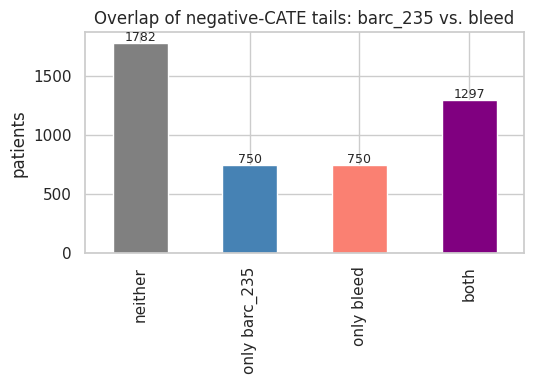

In [6]:
categories = pd.Series({
    'neither': neither.sum(),
    'only barc_235': only_barc.sum(),
    'only bleed': only_bleed.sum(),
    'both': both_neg.sum(),
})

fig, ax = plt.subplots(figsize=(5.5, 4))
categories.plot(kind='bar', color=['grey', 'steelblue', 'salmon', 'purple'], ax=ax)
ax.set_ylabel('patients')
ax.set_title('Overlap of negative-CATE tails: barc_235 vs. bleed')
for i, v in enumerate(categories.values):
    ax.text(i, v + 15, str(v), ha='center', fontsize=9)
plt.tight_layout()
os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(os.path.join(SAVE_DIR, 'negative_subgroup_overlap.png'), dpi=300)
plt.show()

## 5. What characterizes negative-CATE patients? — standardized mean differences

For every covariate we compute the **standardized mean difference** (SMD) between the
negative-CATE and positive-CATE groups,

$$\text{SMD} = \frac{\bar x_{\text{neg}} - \bar x_{\text{pos}}}{\sqrt{(s^2_{\text{neg}} + s^2_{\text{pos}})/2}}$$

the usual covariate-balance metric (|SMD| > 0.1 is the conventional "non-trivial imbalance"
threshold). A Mann-Whitney U test (with Benjamini-Hochberg FDR correction across all 63
covariates) is reported alongside as a secondary, distribution-free check — but given §7-8 of
notebook 08 already found no covariate meaningfully drives the predicted CATE, we do not expect
anything to survive multiple-testing correction.

In [7]:
def smd_table(X_df, mask):
    pos_grp, neg_grp = X_df[~mask], X_df[mask]
    smd = (neg_grp.mean() - pos_grp.mean()) / np.sqrt((neg_grp.var() + pos_grp.var()) / 2)

    pvals = np.array([
        stats.mannwhitneyu(neg_grp[c], pos_grp[c]).pvalue
        if neg_grp[c].nunique() > 1 and pos_grp[c].nunique() > 1 else np.nan
        for c in X_df.columns
    ])
    qvals = multipletests(np.nan_to_num(pvals, nan=1.0), method='fdr_bh')[1]

    out = pd.DataFrame({'SMD': smd, 'p_value': pvals, 'q_value': qvals}, index=X_df.columns)
    return out.reindex(out['SMD'].abs().sort_values(ascending=False).index)


smd_tables = {label: smd_table(X_imp_df, neg[label]) for _, label in ENDPOINTS}

for _, label in ENDPOINTS:
    print(f'--- top |SMD| covariates, negative-CATE {label} vs. rest of cohort ---')
    display(smd_tables[label].head(10))

n_sig = {label: int((smd_tables[label]['q_value'] < 0.05).sum()) for _, label in ENDPOINTS}
print(f'Covariates surviving FDR<0.05: {n_sig}')

--- top |SMD| covariates, negative-CATE barc_235 vs. rest of cohort ---


,SMD,p_value,q_value
bp_sys,0.520,0.000,0.000
fup_insulin,0.393,0.000,0.000
p_bleed_action1_rece,0.354,0.000,0.000
p_bleed,0.300,0.000,0.000
p_bleed_action1_none,-0.296,0.000,0.000
afib_yes_paroxysmal,-0.280,0.000,0.000
diabetes_type_ii_in1,0.280,0.000,0.000
prec_priorbleed,0.269,0.000,0.000
afib_yes - permanent,0.247,0.000,0.000
diabetes_type_ii_die,-0.246,0.000,0.000


--- top |SMD| covariates, negative-CATE bleed vs. rest of cohort ---


,SMD,p_value,q_value
alcohol_yes_less_tha,-0.385,0.000,0.000
afib_yes_persistent,0.361,0.000,0.000
smoker_yes_previous,-0.304,0.000,0.000
afib_yes_paroxysmal,-0.268,0.000,0.000
rand_oac12,0.247,0.000,0.000
prior_cabg,0.231,0.000,0.000
bp_sys,0.210,0.000,0.000
bmi,0.208,0.000,0.000
p_bleed_action1_rece,0.196,0.000,0.000
ic_age_mon,-0.194,0.000,0.001


Covariates surviving FDR<0.05: {'barc_235': 36, 'bleed': 35}


## 6. Visualizing the strongest covariates

The covariates with the largest |SMD| for either endpoint, plotted side by side for both
endpoints so it is clear whether the same variables separate the two tails.

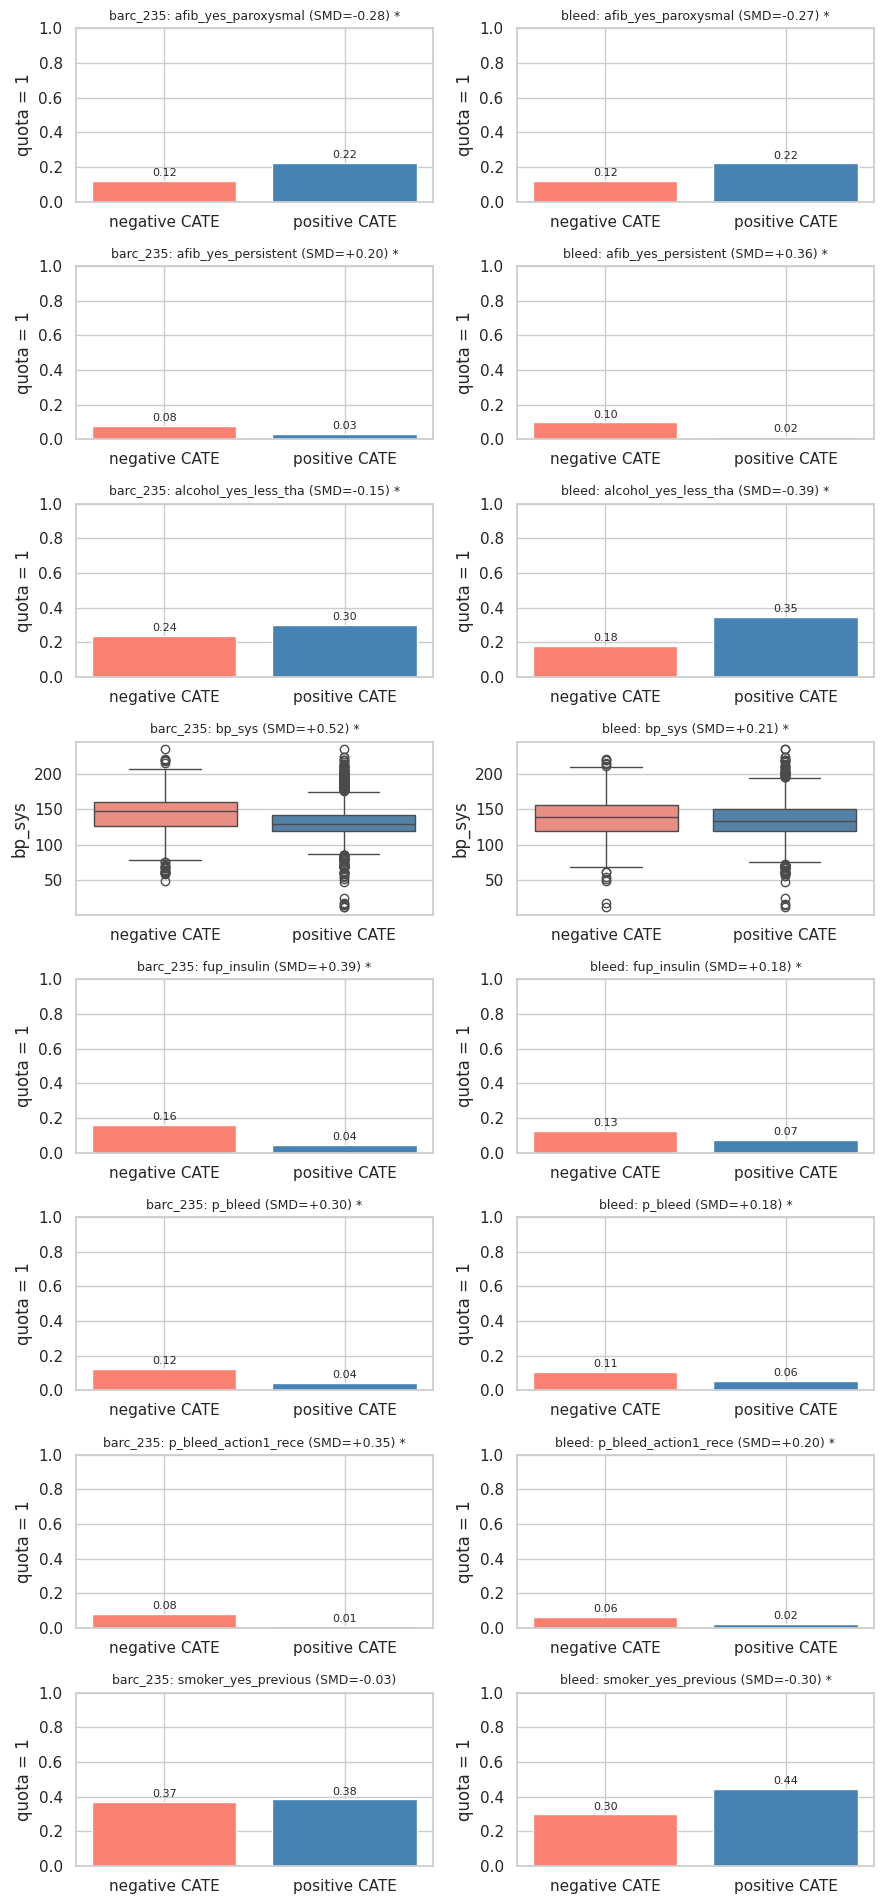

In [8]:
top_feats = sorted(set(smd_tables['barc_235'].head(4).index) |
                    set(smd_tables['bleed'].head(4).index))

# Fixed group order + colours so every panel reads left=negative (salmon),
# right=positive (steelblue) — the boxplot version let seaborn reorder them per column.
ORDER = ['negative CATE', 'positive CATE']
PALETTE = {'negative CATE': 'salmon', 'positive CATE': 'steelblue'}


def plot_covariate_panel(ax, feat, mask):
    """Draw one covariate panel with the right mark for the variable type.

    `mask` is True for the negative-CATE group. Binary covariates (most of the top-|SMD|
    ones) are shown as the *share of 1s* in each group — a boxplot collapses them onto 0
    with the 1s as outlier dots. `bp_sys` is the only continuous covariate and keeps a boxplot.
    """
    if X_imp_df[feat].nunique() <= 2:                       # binary -> proportion bars
        props = [X_imp_df.loc[mask, feat].mean(), X_imp_df.loc[~mask, feat].mean()]
        ax.bar_label(ax.bar(ORDER, props, color=[PALETTE[g] for g in ORDER]),
                     fmt='%.2f', padding=2, fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_ylabel('quota = 1')
    else:                                                   # continuous -> boxplot
        group = np.where(mask, 'negative CATE', 'positive CATE')
        sns.boxplot(x=group, y=X_imp_df[feat], order=ORDER, hue=group, hue_order=ORDER,
                    palette=PALETTE, legend=False, ax=ax)
    ax.set_xlabel('')


fig, axes = plt.subplots(len(top_feats), 2, figsize=(9, 2.4 * len(top_feats)),
                         squeeze=False)

for i, feat in enumerate(top_feats):
    for j, (_, label) in enumerate(ENDPOINTS):
        ax = axes[i, j]
        plot_covariate_panel(ax, feat, neg[label])
        row = smd_tables[label].loc[feat]
        star = ' *' if row['q_value'] < 0.05 else ''       # * = survives FDR<0.05
        ax.set_title(f'{label}: {feat} (SMD={row["SMD"]:+.2f}){star}', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'negative_subgroup_covariates.png'), dpi=300)
plt.show()

## 7. Observed outcome & treatment mix within subgroups (descriptive only)

A sanity-check crosstab: within each subgroup, the observed (not model-predicted) event rate
under each treatment arm. This is **purely descriptive** — the subgroup is defined post-hoc by
the model's own prediction on the same patients it was fit to (in-sample), the negative-CATE
tail is small, and no adjustment is made for confounding here. It should not be read as a causal
estimate for the subgroup.

In [9]:
rows = []
for target, label in ENDPOINTS:
    for grp_name, mask in [('negative CATE', neg[label]), ('positive CATE', ~neg[label])]:
        sub_T = T[mask]
        sub_y = y_df[target].to_numpy()[mask]
        rows.append({
            'endpoint': label,
            'group': grp_name,
            'n': int(mask.sum()),
            'pct_prolonged_DAPT': sub_T.mean(),
            'event_rate | prolonged': sub_y[sub_T == 1].mean() if (sub_T == 1).any() else np.nan,
            'event_rate | abbreviated': sub_y[sub_T == 0].mean() if (sub_T == 0).any() else np.nan,
        })

desc = pd.DataFrame(rows).set_index(['endpoint', 'group'])
display(desc)

n  pct_prolonged_DAPT  event_rate | prolonged  \
endpoint group                                                             
barc_235 negative CATE  2047               0.493                   0.040   
         positive CATE  2532               0.504                   0.134   
bleed    negative CATE  2047               0.501                   0.040   
         positive CATE  2532               0.497                   0.209   

                        event_rate | abbreviated  
endpoint group                                    
barc_235 negative CATE                     0.102  
         positive CATE                     0.033  
bleed    negative CATE                     0.152  
         positive CATE                     0.037

## 8. Conclusion

- **Not a small tail.** §3 shows 44.7% of the cohort (2047/4579) has a negative predicted CATE
  for *both* `barc_235` and `bleed` individually — the low, harmful ATE for these endpoints sits
  inside a CATE distribution wide enough that a large share of patients fall on the "protective"
  side of zero. That alone is a first piece of evidence against a compact, identifiable
  "protected" phenotype: it is closer to a coin flip than to a rare subgroup.
- **Only partial overlap between endpoints.** §4: of the 2047 patients negative on `barc_235`
  and the 2047 negative on `bleed`, only 1297 (63%) are negative on *both* — more than the ~914
  expected if the two sign splits were independent, but far from the ~100% a single stable
  "non-bleeder" phenotype would require. A patient flagged as protected under one bleeding
  definition is unreliably flagged under the other.
- **Some covariates do differ, but weakly-to-moderately.** §5: 35-36 of 63 covariates survive
  FDR<0.05 (large n makes even small differences significant), with the largest standardized
  mean differences (`bp_sys`, prior-bleeding history/action, insulin use, atrial-fibrillation
  subtype, diabetes subtype, alcohol/smoking history, prior CABG) in the SMD≈0.2–0.5 range —
  small-to-moderate, and roughly consistent with the weak Spearman associations (|ρ| ≤ 0.213)
  already found in `08_CausalFPN.ipynb` §7 once you convert between the two metrics. These are
  plausible bleeding-risk modifiers, but none is a strong, dominant driver.
- **§7's dramatic-looking split is an in-sample artifact, not evidence of real heterogeneity.**
  The observed event rates by treatment arm track the predicted sign almost perfectly (e.g.
  `bleed`: negative-CATE group 4.0% under prolonged vs. 15.2% under abbreviated; positive-CATE
  group 20.9% vs. 3.7%). This looks striking, but CausalPFN's CATE is itself built from
  comparing each patient's near-neighbours' *observed* outcomes under each treatment — checking
  the observed rates back against the model's own sign split on the *same* data it was fit to is
  close to circular, and is exactly the kind of in-sample overfitting that notebook 08's honest
  held-out RATE/TOC test (§8, AUTOC ≈ 0) was designed to catch, and did catch.

**Bottom line:** the negative-CATE group is large, only partly stable across the two related
bleeding endpoints, and only weakly-to-moderately associated with baseline covariates — this is
the same **model noise / instability** already flagged in notebook 08 (§7-8) and in the
T-learner / causal forest analyses, not a reproducible responder subgroup. The actionable
estimate remains the population-level ATE (prolonged DAPT: bleeding excess, small ischemic
benefit), not per-patient targeting based on the predicted CATE sign.